# Points to Tract Processor Demo

This notebook demonstrates how to use `PointsToTractProcessor` to aggregate Airbnb point data to census tracts.


In [ ]:
import sys

sys.path.insert(0, "/project/src")

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

from housing.components.loaders.tract_boundaries import TractBoundariesLoader
from housing.components.processors.points_to_tract import PointsToTractProcessor
from pipeline import Pipeline
from pipeline.config import PipelineConfig

## Step 1: Create Custom Loader for Airbnb Points

First, we'll create a simple loader component to load Airbnb data as points.


In [7]:
from typing import Any

from pipeline.base import DataLoader


class AirbnbPointLoader(DataLoader):
    """Load Airbnb listings as point data."""

    def __init__(self) -> None:
        """Initialize the Airbnb point loader."""
        super().__init__("airbnb_point_loader", "Load Airbnb listings as points")

    def execute(self, context: dict[str, Any]) -> dict[str, Any]:
        """Execute the loader to load Airbnb listings as GeoDataFrame.

        Args:
            context: Pipeline context (unused in this loader)

        Returns:
            Dictionary with 'airbnb_points' key containing GeoDataFrame
        """
        # Load data
        listings_df = pd.read_csv("/project/data/listings.csv")

        # Convert price from string to numeric (remove $ and convert)
        listings_df["price"] = (
            listings_df["price"].str.replace("$", "").str.replace(",", "").astype(float)
        )

        # Create GeoDataFrame
        gdf = gpd.GeoDataFrame(
            listings_df,
            geometry=gpd.points_from_xy(listings_df.longitude, listings_df.latitude),
            crs="EPSG:4326",
        )

        print(f"Loaded {len(gdf)} Airbnb point locations")
        return {"airbnb_points": gdf}

## Step 2: Set Up Pipeline with PointsToTractProcessor

Now we'll create a pipeline that aggregates Airbnb points to census tracts.


In [8]:
# Create pipeline
config = PipelineConfig()
pipeline = Pipeline("Airbnb Points to Tracts", config=config)

# Load data
pipeline.register_component(AirbnbPointLoader())
pipeline.register_component(TractBoundariesLoader())

# Configure PointsToTractProcessor
points_processor = PointsToTractProcessor(
    input_key="airbnb_points",  # Input: point data from AirbnbPointLoader
    output_key="airbnb_tracts",  # Output: tract-level aggregated data
    id_column="id",  # Column with listing IDs
    aggregate_columns={
        "price": ["mean", "median", "min", "max"],
        "accommodates": "mean",
        "bedrooms": "mean",
    },
    calculate_density=True,  # Calculate listings per km²
)

pipeline.register_component(points_processor)

# Execute
results = pipeline.execute()

INFO:pipeline.base:Registered component: airbnb_point_loader
INFO:pipeline.base:Registered component: tract_boundaries
INFO:pipeline.base:Registered component: points_to_tract_airbnb_points
INFO:pipeline.base:Starting pipeline execution: Airbnb Points to Tracts
INFO:pipeline.base:Components to execute: ['airbnb_point_loader', 'tract_boundaries', 'points_to_tract_airbnb_points']
INFO:pipeline.base:Executing component: airbnb_point_loader
INFO:pipeline.base:Executing component: tract_boundaries
INFO:housing.components.loaders.tract_boundaries:Loading census tract boundaries from: /project/data/tl_2023_17_tract/tl_2023_17_tract.shp


Loaded 8604 Airbnb point locations


INFO:housing.components.loaders.tract_boundaries:Filtered to Cook County (Chicago)
INFO:housing.components.loaders.tract_boundaries:Loaded 1332 census tract boundaries
INFO:housing.components.loaders.tract_boundaries:CRS: EPSG:4269
INFO:housing.components.loaders.tract_boundaries:Sample tract GEOIDs: ['17031807100', '17031030101', '17031030701']
INFO:pipeline.base:Executing component: points_to_tract_airbnb_points
INFO:housing.components.processors.points_to_tract:Aggregating airbnb_points point data to census tracts...
INFO:housing.components.processors.points_to_tract:Step 1: Aligning coordinate systems...
INFO:housing.components.processors.points_to_tract:Step 2: Spatial join (points → tracts)...
INFO:housing.components.processors.points_to_tract:Matched 8604/8604 points to census tracts (100.0%)
INFO:housing.components.processors.points_to_tract:Step 3: Aggregating by census tract...
INFO:housing.components.processors.points_to_tract:Aggregated to 678 census tracts
INFO:housing.com

## Step 3: Examine Results

Let's look at the aggregated tract-level data.


In [9]:
# Get results
airbnb_tracts = pipeline.context["airbnb_tracts"]

print(f"Aggregated to {len(airbnb_tracts)} census tracts")
print(f"\nColumns: {airbnb_tracts.columns.tolist()}")
print(f"\nTracts with Airbnb: {(airbnb_tracts['point_count'] > 0).sum()}")
print(f"Tracts without Airbnb: {(airbnb_tracts['point_count'] == 0).sum()}")

# Show summary statistics
tracts_with_airbnb = airbnb_tracts[airbnb_tracts["point_count"] > 0]
print("\nSummary (tracts with Airbnb):")
print(f"  Total listings: {tracts_with_airbnb['point_count'].sum():.0f}")
print(f"  Avg listings per tract: {tracts_with_airbnb['point_count'].mean():.1f}")
print(f"  Max listings: {tracts_with_airbnb['point_count'].max():.0f}")
print(f"  Avg density: {tracts_with_airbnb['point_density'].mean():.2f} listings/km²")
print(f"  Avg price: ${tracts_with_airbnb['price_mean'].mean():.2f}")

# Top 10 by density
print("\nTop 10 tracts by density:")
airbnb_tracts.nlargest(10, "point_density")[
    ["tract_geoid", "point_count", "point_density", "price_mean"]
]

Aggregated to 1332 census tracts

Columns: ['tract_geoid', 'geometry', 'point_count', 'price_mean', 'price_median', 'price_min', 'price_max', 'accommodates_mean', 'bedrooms_mean', 'area_km2', 'point_density']

Tracts with Airbnb: 678
Tracts without Airbnb: 654

Summary (tracts with Airbnb):
  Total listings: 8604
  Avg listings per tract: 12.7
  Max listings: 217
  Avg density: 32.34 listings/km²
  Avg price: $262.38

Top 10 tracts by density:


,tract_geoid,point_count,point_density,price_mean
806,17031081500,176.0,595.416593,310.641379
808,17031081700,135.0,363.595186,7212.096774
807,17031081600,46.0,346.645011,373.800000
100,17031320102,153.0,319.943594,433.022472
724,17031081000,88.0,294.700297,349.977011
863,17031061100,50.0,289.168788,416.187500
63,17031330103,132.0,259.182757,312.147287
723,17031081300,52.0,256.777332,11007.136364
1105,17031081201,43.0,232.448306,569.581395
771,17031410200,15.0,231.555764,119.076923


## Step 4: Visualize Density Maps


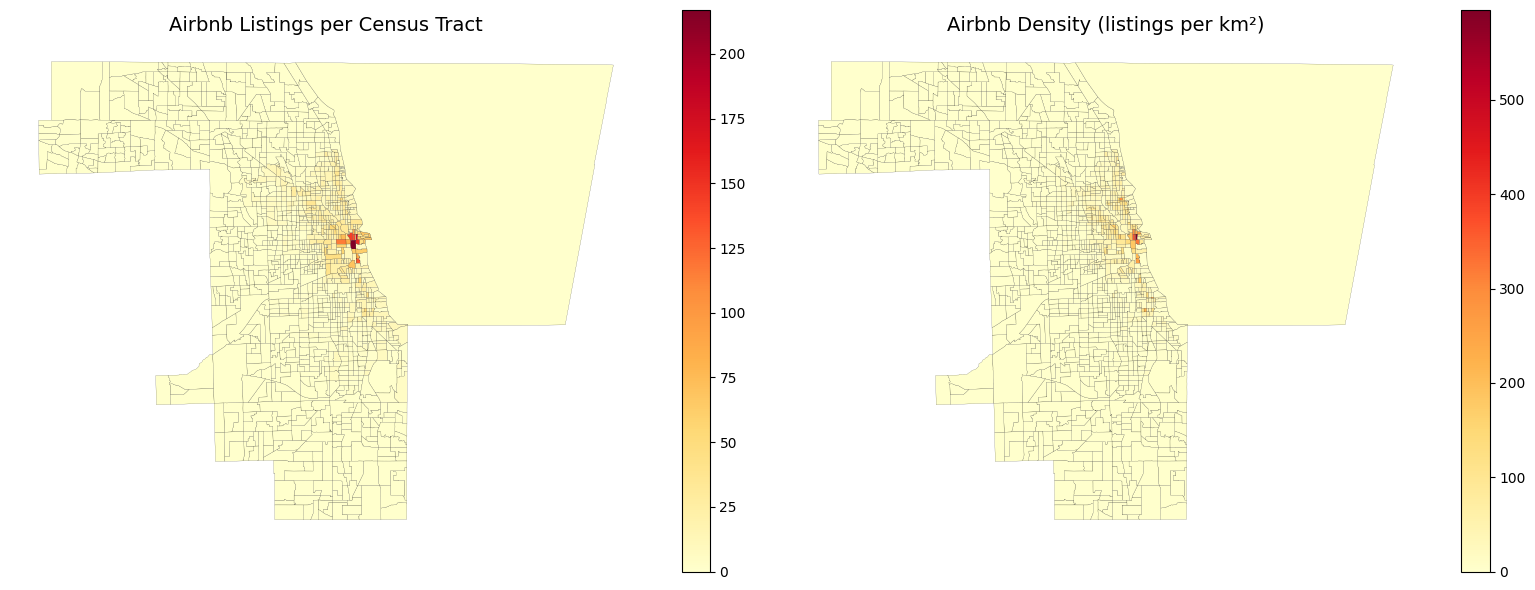

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Count per tract
airbnb_tracts.plot(
    column="point_count",
    cmap="YlOrRd",
    legend=True,
    ax=ax1,
    edgecolor="black",
    linewidth=0.1,
)
ax1.set_title("Airbnb Listings per Census Tract", fontsize=14)
ax1.axis("off")

# Plot 2: Density per km²
airbnb_tracts.plot(
    column="point_density",
    cmap="YlOrRd",
    legend=True,
    ax=ax2,
    edgecolor="black",
    linewidth=0.1,
)
ax2.set_title("Airbnb Density (listings per km²)", fontsize=14)
ax2.axis("off")

plt.tight_layout()
plt.savefig("/project/output/airbnb_tract_density.png", dpi=300, bbox_inches="tight")
plt.show()

## Key Takeaways

**What `PointsToTractProcessor` did for us:**
- Spatial join: Matched each Airbnb listing to its census tract
- Aggregation: Counted listings and calculated price statistics per tract
- Density calculation: Computed listings per km² (with proper UTM projection)
- Geometry: Returned tract polygons ready for mapping

**Configuration we used:**
```python
PointsToTractProcessor(
    input_key="airbnb_points",          # Our point data
    output_key="airbnb_tracts",         # Tract-level output
    id_column="id",                     # Count by listing ID
    aggregate_columns={                 # Custom aggregations
        "price": ["mean", "median", "min", "max"],
        "accommodates": "mean",
        "bedrooms": "mean",
    },
    calculate_density=True              # Points per km²
)
```
